Hasil Perbandingan Jarak:
Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


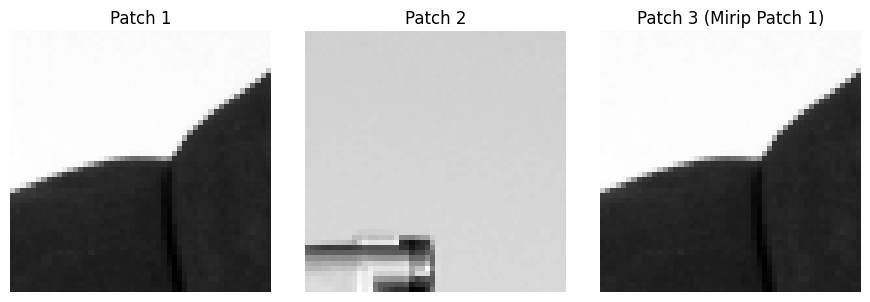

In [ ]:
# Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Membuat patch citra
def create_image_patches():
    # Load gambar dan konversi ke float
    image = img_as_float(data.camera())
    
    # Membuat tiga patch berbeda
    patch1 = image[100:150, 100:150]          # Patch original
    patch2 = image[100:150, 300:350]          # Patch dari lokasi berbeda
    patch3 = patch1 + 0.1                     # Patch1 dengan sedikit noise
    patch3 = np.clip(patch3, 0, 1)            # Pastikan nilai tetap dalam range [0,1]
    
    return patch1, patch2, patch3

# 2. Flatten patch menjadi vektor 1D
def flatten_patches(patch1, patch2, patch3):
    vec1 = patch1.flatten()
    vec2 = patch2.flatten()
    vec3 = patch3.flatten()
    return vec1, vec2, vec3

# 3. Hitung jarak antar vektor
def calculate_distances(vec1, vec2, vec3):
    # Euclidean distance (L2)
    dist_l2_12 = distance.euclidean(vec1, vec2)
    dist_l2_13 = distance.euclidean(vec1, vec3)
    
    # Manhattan distance (L1)
    dist_l1_12 = distance.cityblock(vec1, vec2)
    dist_l1_13 = distance.cityblock(vec1, vec3)
    
    return dist_l2_12, dist_l2_13, dist_l1_12, dist_l1_13

# 4. Tampilkan hasil
def display_results(dist_l2_12, dist_l2_13, dist_l1_12, dist_l1_13):
    print("Hasil Perbandingan Jarak:")
    print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
    print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
    print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
    print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

# 5. Visualisasi patch
def visualize_patches(patch1, patch2, patch3):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    
    axes[0].imshow(patch1, cmap='gray')
    axes[0].set_title('Patch 1')
    axes[0].axis('off')
    
    axes[1].imshow(patch2, cmap='gray')
    axes[1].set_title('Patch 2')
    axes[1].axis('off')
    
    axes[2].imshow(patch3, cmap='gray')
    axes[2].set_title('Patch 3 (Mirip Patch 1)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Main program
def main():
    # 1. Buat patch citra
    patch1, patch2, patch3 = create_image_patches()
    
    # 2. Flatten patch menjadi vektor
    vec1, vec2, vec3 = flatten_patches(patch1, patch2, patch3)
    
    # 3. Hitung jarak
    distances = calculate_distances(vec1, vec2, vec3)
    
    # 4. Tampilkan hasil
    display_results(*distances)
    
    # 5. Visualisasi
    visualize_patches(patch1, patch2, patch3)

if __name__ == "__main__":
    main()


Hasil Cosine Similarity:
Image 1 vs Image 2 (berbeda): 0.8156
Image 1 vs Image 3 (sama): 1.0000
Image 1 vs Image 4 (downsampled): 1.0000


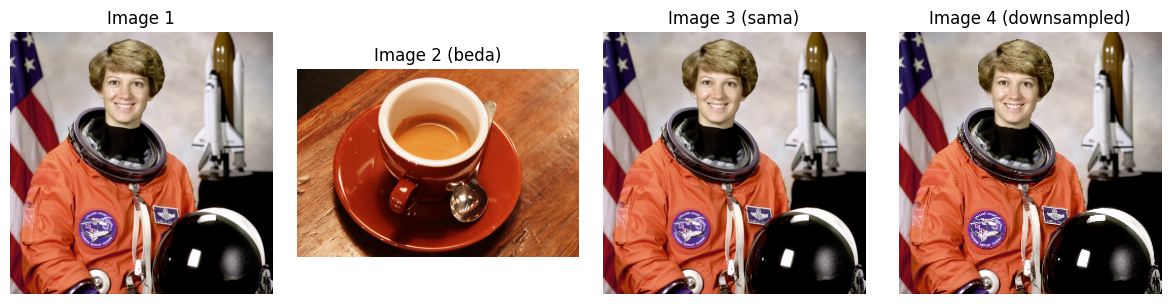

In [ ]:
# Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    """
    Menghitung histogram gabungan RGB dari citra berwarna
    
    Parameters:
        image : ndarray
            Citra input dalam format RGB
        bins : int
            Jumlah bin untuk histogram
            
    Returns:
        ndarray: Vektor histogram gabungan yang dinormalisasi
    """
    # Konversi ke uint8 untuk memastikan range nilai 0-255
    img_uint8 = img_as_ubyte(image)
    
    # Hitung histogram untuk masing-masing channel
    hist_r, _ = np.histogram(img_uint8[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:,:,2].ravel(), bins=bins, range=(0, 256))
    
    # Gabungkan dan normalisasi histogram
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)
    
    return hist_combined

def load_sample_images():
    """
    Memuat contoh citra untuk analisis
    
    Returns:
        tuple: Empat citra contoh (image1, image2, image3, image4)
    """
    try:
        # Gunakan citra dari skimage
        image1 = data.astronaut()
        image2 = data.coffee()          # Citra yang berbeda
        image3 = data.astronaut()       # Citra yang sama
        image4 = image1[::2, ::2, :]    # Versi downsampled
    except Exception as e:
        print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
        # Fallback ke citra acak jika gagal
        image1 = np.random.rand(100, 100, 3)
        image2 = np.random.rand(100, 100, 3) * 0.5
        image3 = image1.copy()
        image4 = image1[::2, ::2, :]
    
    return image1, image2, image3, image4

def calculate_similarities(hist1, hist2, hist3, hist4):
    """
    Menghitung cosine similarity antara histogram
    
    Parameters:
        hist1-4 : ndarray
            Vektor histogram untuk perbandingan
            
    Returns:
        tuple: Nilai similarity (sim_12, sim_13, sim_14)
    """
    # Hitung cosine similarity (1 - cosine distance)
    sim_12 = 1 - distance.cosine(hist1, hist2)
    sim_13 = 1 - distance.cosine(hist1, hist3)
    sim_14 = 1 - distance.cosine(hist1, hist4)
    
    return sim_12, sim_13, sim_14

def display_results(sim_12, sim_13, sim_14):
    """Menampilkan hasil perbandingan similarity"""
    print("\nHasil Cosine Similarity:")
    print(f"Image 1 vs Image 2 (berbeda): {sim_12:.4f}")
    print(f"Image 1 vs Image 3 (sama): {sim_13:.4f}")
    print(f"Image 1 vs Image 4 (downsampled): {sim_14:.4f}")

def visualize_images(images, titles):
    """Visualisasi citra untuk perbandingan"""
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def main():
    # 1. Muat citra contoh
    image1, image2, image3, image4 = load_sample_images()
    
    # 2. Hitung histogram
    hist1 = calculate_rgb_histogram(image1)
    hist2 = calculate_rgb_histogram(image2)
    hist3 = calculate_rgb_histogram(image3)
    hist4 = calculate_rgb_histogram(image4)
    
    # 3. Hitung similarity
    sim_12, sim_13, sim_14 = calculate_similarities(hist1, hist2, hist3, hist4)
    
    # 4. Tampilkan hasil
    display_results(sim_12, sim_13, sim_14)
    
    # 5. Visualisasi
    images = [image1, image2, image3, image4]
    titles = ['Image 1', 'Image 2 (beda)', 'Image 3 (sama)', 'Image 4 (downsampled)']
    visualize_images(images, titles)

if __name__ == "__main__":
    main()

SSIM Comparison Results:
Reference vs Same: 1.0000
Reference vs Noisy: 0.2952
Reference vs Contrast: 0.9651
Reference vs Blurred: 0.8027


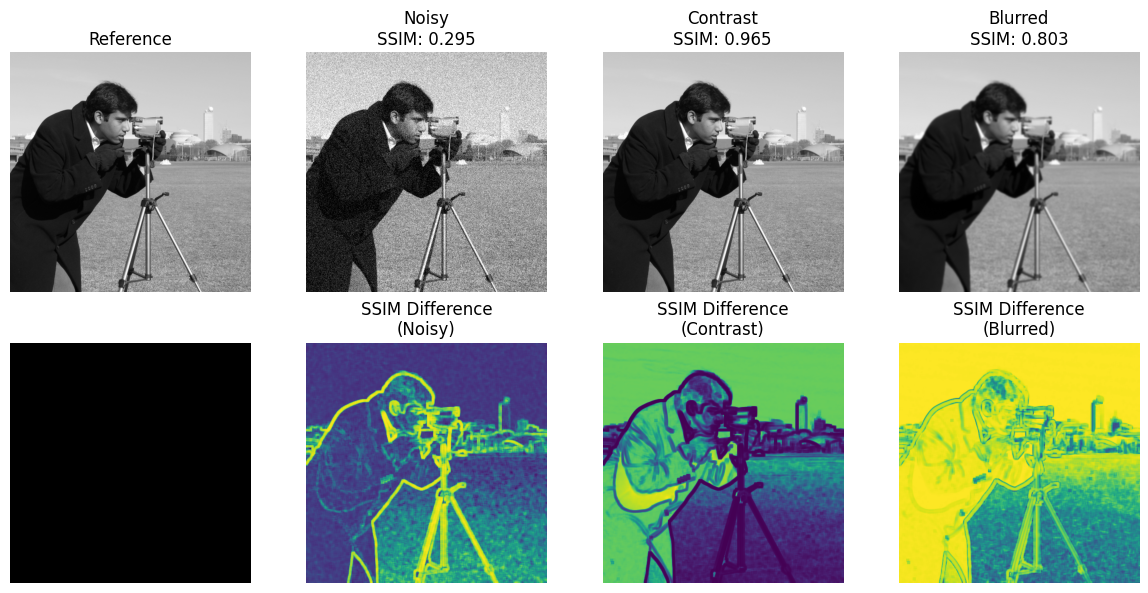

In [ ]:
# Praktikum 3. Menghitung Structural Similarity Index (SSIM) 
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.util import random_noise
from skimage.filters import gaussian

def load_and_process_images():
    """Load reference image and create distorted versions"""
    # 1. Load reference image
    image_ref = img_as_float(data.camera())
    
    # 2. Create distorted versions
    image_same = image_ref.copy()  # a) Identical image
    image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)  # b) Noisy version
    image_contrast = np.clip(image_ref * 0.8, 0, 1)  # c) Lower contrast
    image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # d) Blurred version
    
    return image_ref, image_same, image_noisy, image_contrast, image_blurred

def calculate_ssim_scores(image_ref, distorted_images):
    """Calculate SSIM scores between reference and distorted images"""
    data_range = image_ref.max() - image_ref.min()
    ssim_scores = []
    diff_images = []
    
    for img in distorted_images:
        score, diff = ssim(image_ref, img, 
                          data_range=data_range, 
                          full=True)
        ssim_scores.append(score)
        diff_images.append(diff)
    
    return ssim_scores, diff_images

def display_results(images, titles, diff_images):
    """Display images and results"""
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    
    # Display original and distorted images
    for i in range(4):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    # Placeholder for alignment
    axes[4].imshow(np.zeros_like(images[0]), cmap='gray')
    axes[4].set_title('')
    axes[4].axis('off')
    
    # Display difference maps
    for i in range(3):
        title_part = titles[i+1].split('\n')[0]  # Extract first part before newline
        axes[5+i].imshow(diff_images[i], cmap='viridis')
        axes[5+i].set_title(f'SSIM Difference\n({title_part})')
        axes[5+i].axis('off')
    
    plt.tight_layout()
    plt.show()

def main():
    # Load and process images
    image_ref, image_same, image_noisy, image_contrast, image_blurred = load_and_process_images()
    
    # Prepare distorted images list
    distorted_images = [image_same, image_noisy, image_contrast, image_blurred]
    
    # Calculate SSIM scores first
    ssim_scores, diff_images = calculate_ssim_scores(image_ref, distorted_images)
    
    # Print results
    print("SSIM Comparison Results:")
    print(f"Reference vs Same: {ssim_scores[0]:.4f}")
    print(f"Reference vs Noisy: {ssim_scores[1]:.4f}")
    print(f"Reference vs Contrast: {ssim_scores[2]:.4f}")
    print(f"Reference vs Blurred: {ssim_scores[3]:.4f}")
    
    # Create titles after we have the SSIM scores
    titles = [
        'Reference',
        f'Noisy\nSSIM: {ssim_scores[1]:.3f}',
        f'Contrast\nSSIM: {ssim_scores[2]:.3f}',
        f'Blurred\nSSIM: {ssim_scores[3]:.3f}'
    ]
    
    # Display results
    display_images = [image_ref, image_noisy, image_contrast, image_blurred]
    display_results(display_images, titles, diff_images[1:])

if __name__ == "__main__":
    main()

Template found at coordinates (x,y): (190, 15)


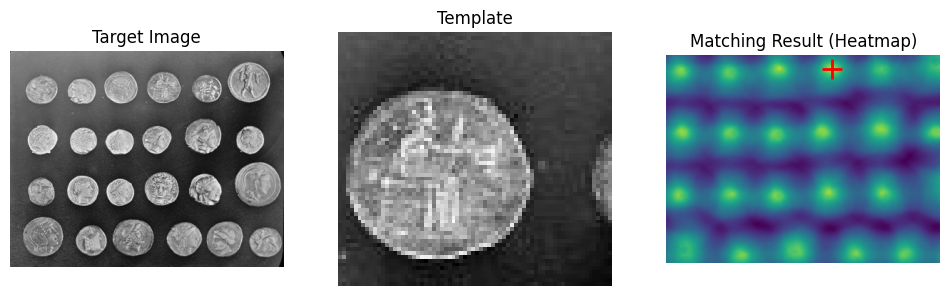

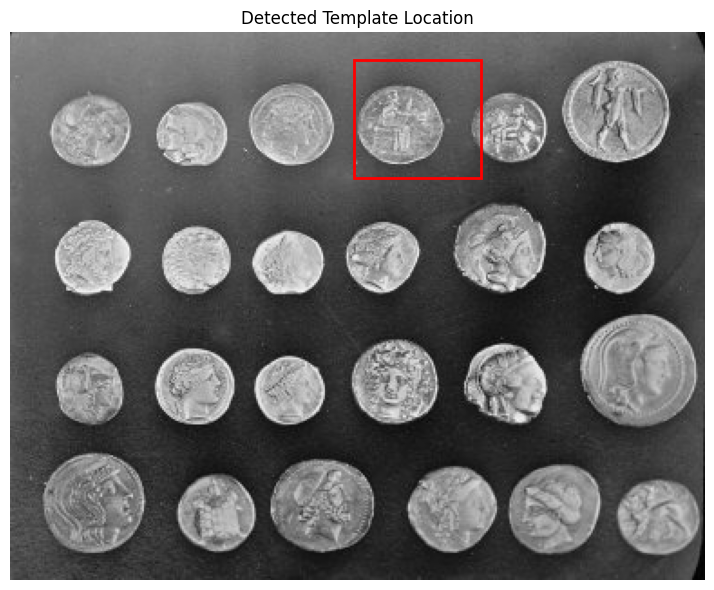

In [ ]:
# Praktikum 4. Penerapan Template Matching 
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

def load_images():
    """Load target image and extract template"""
    image = data.coins()
    template = image[15:80, 190:260]  # Extract one coin as template
    return image, template

def perform_template_matching(image, template):
    """Perform template matching using normalized cross-correlation"""
    result = match_template(image, template)
    return result

def find_best_match(result):
    """Find location with highest matching score"""
    ij = np.unravel_index(np.argmax(result), result.shape)
    x, y = ij[::-1]  # Convert to (x, y) coordinates
    return x, y

def visualize_results(image, template, result, x, y):
    """Visualize the matching results"""
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Plot target image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Target Image')
    axes[0].set_axis_off()
    
    # Plot template
    axes[1].imshow(template, cmap='gray')
    axes[1].set_title('Template')
    axes[1].set_axis_off()
    
    # Plot heatmap with best match marked
    axes[2].imshow(result, cmap='viridis')
    axes[2].set_title('Matching Result (Heatmap)')
    axes[2].set_axis_off()
    axes[2].plot(x, y, 'r+', markersize=15, markeredgewidth=2)
    
    # Create separate figure for the final result
    fig2, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image, cmap='gray')
    ax.set_title('Detected Template Location')
    ax.set_axis_off()
    
    # Draw rectangle around matched template
    h, w = template.shape
    rect = plt.Rectangle((x, y), w, h, edgecolor='red', 
                         facecolor='none', linewidth=2)
    ax.add_patch(rect)
    
    plt.tight_layout()
    plt.show()

def main():
    # 1. Load images
    image, template = load_images()
    
    # 2. Perform template matching
    result = perform_template_matching(image, template)
    
    # 3. Find best match location
    x, y = find_best_match(result)
    
    # 4. Print and visualize results
    print(f"Template found at coordinates (x,y): ({x}, {y})")
    visualize_results(image, template, result, x, y)

if __name__ == "__main__":
    main()

Processing image database...
- astronaut processed successfully
- camera processed successfully
- coffee processed successfully
- coins processed successfully
- chelsea processed successfully

Retrieval results (left to right: most to least similar):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


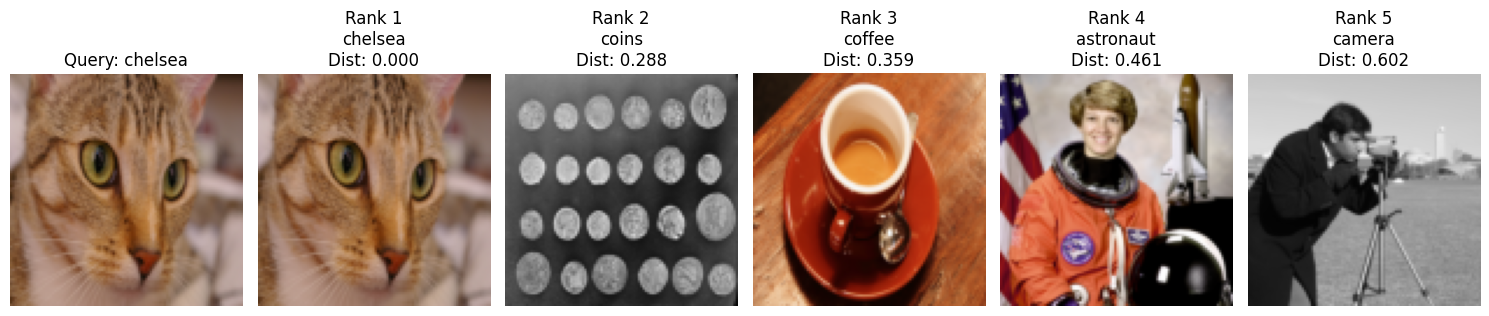

In [ ]:
# Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

def calculate_rgb_histogram(image, bins=16):
    """Calculate normalized RGB histogram for an image"""
    # Convert to uint8 if image is float
    if image.dtype == float:
        image = img_as_ubyte(image)
    
    # Calculate histograms for each channel
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    
    # Combine and normalize
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    return hist_combined

def load_and_process_images(image_names, target_size=(100, 100)):
    """Load and preprocess images from skimage.data"""
    database_images = []
    database_hists = []
    
    print("Processing image database...")
    for name in image_names:
        try:
            img = getattr(data, name)()
            
            # Convert grayscale to RGB
            if img.ndim == 2:
                img = color.gray2rgb(img)
                
            # Resize to target dimensions
            img_resized = transform.resize(img, target_size, anti_aliasing=True)
            
            database_images.append(img_resized)
            database_hists.append(calculate_rgb_histogram(img_resized))
            print(f"- {name} processed successfully")
        except Exception as e:
            print(f"Error processing {name}: {str(e)}")
            
    return database_images, database_hists

def retrieve_similar_images(query_image, query_hist, database_images, database_hists, image_names):
    """Retrieve and rank images by similarity to query"""
    # Calculate distances
    distances = []
    for hist in database_hists:
        dist = distance.cosine(query_hist, hist)
        distances.append(dist)
    
    # Sort by similarity
    sorted_indices = np.argsort(distances)
    
    return distances, sorted_indices

def display_results(query_image, query_name, database_images, image_names, distances, sorted_indices):
    """Visualize query and ranked results"""
    num_results = len(database_images)
    fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))
    
    # Show query image
    axes[0].imshow(query_image)
    axes[0].set_title(f"Query: {query_name}")
    axes[0].axis('off')
    
    # Show ranked results
    print("\nRetrieval results (left to right: most to least similar):")
    for i, idx in enumerate(sorted_indices):
        rank = i + 1
        axes[rank].imshow(database_images[idx])
        axes[rank].set_title(f"Rank {rank}\n{image_names[idx]}\nDist: {distances[idx]:.3f}")
        axes[rank].axis('off')
        print(f"Rank {rank}: {image_names[idx]} (Distance: {distances[idx]:.3f})")
    
    plt.tight_layout()
    plt.show()

def main():
    # 1. Prepare image database
    image_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
    database_images, database_hists = load_and_process_images(image_names)
    
    # 2. Select query image (chelsea the cat)
    query_name = "chelsea"
    query_index = image_names.index(query_name)
    query_image = database_images[query_index]
    query_hist = database_hists[query_index]
    
    # 3. Perform retrieval
    distances, sorted_indices = retrieve_similar_images(
        query_image, query_hist, database_images, database_hists, image_names
    )
    
    # 4. Display results
    display_results(
        query_image, query_name, database_images, image_names, distances, sorted_indices
    )

if __name__ == "__main__":
    main()

Processing image database...
- astronaut processed
- camera processed
- coffee processed
- coins processed
- chelsea processed

Retrieval results (Euclidean distance on mean color):
Rank 1: chelsea (Distance: 0.000)
Rank 2: astronaut (Distance: 0.050)
Rank 3: coffee (Distance: 0.176)
Rank 4: camera (Distance: 0.194)
Rank 5: coins (Distance: 0.211)


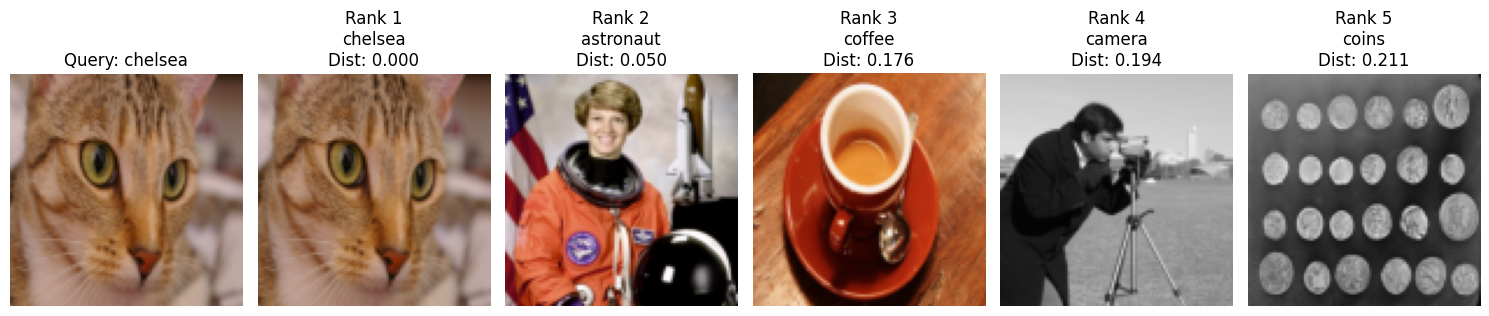

In [ ]:
# Soal Penugasan No 3
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform
from scipy.spatial import distance

def calculate_mean_color(image):
    """Calculate mean R, G, B values as 3D feature vector"""
    return np.mean(image, axis=(0,1))  # Returns [mean_R, mean_G, mean_B]

def load_and_process_images(image_names, target_size=(100, 100)):
    """Load images and extract mean color features"""
    database_images = []
    database_features = []
    
    print("Processing image database...")
    for name in image_names:
        try:
            img = getattr(data, name)()
            if img.ndim == 2:
                img = color.gray2rgb(img)
            img_resized = transform.resize(img, target_size, anti_aliasing=True)
            database_images.append(img_resized)
            database_features.append(calculate_mean_color(img_resized))
            print(f"- {name} processed")
        except Exception as e:
            print(f"Error processing {name}: {str(e)}")
            
    return database_images, database_features

def retrieve_similar_images(query_feature, database_features, image_names):
    """Retrieve images using Euclidean distance on mean color"""
    distances = [distance.euclidean(query_feature, feat) for feat in database_features]
    sorted_indices = np.argsort(distances)
    return distances, sorted_indices

def display_results(query_image, query_name, database_images, image_names, distances, sorted_indices):
    """Visualize retrieval results"""
    num_results = len(database_images)
    fig, axes = plt.subplots(1, num_results + 1, figsize=(15, 3))
    
    axes[0].imshow(query_image)
    axes[0].set_title(f"Query: {query_name}")
    axes[0].axis('off')
    
    print("\nRetrieval results (Euclidean distance on mean color):")
    for i, idx in enumerate(sorted_indices):
        rank = i + 1
        axes[rank].imshow(database_images[idx])
        axes[rank].set_title(f"Rank {rank}\n{image_names[idx]}\nDist: {distances[idx]:.3f}")
        axes[rank].axis('off')
        print(f"Rank {rank}: {image_names[idx]} (Distance: {distances[idx]:.3f})")
    
    plt.tight_layout()
    plt.show()

def main():
    image_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
    database_images, database_features = load_and_process_images(image_names)
    
    query_name = "chelsea"
    query_idx = image_names.index(query_name)
    query_feature = database_features[query_idx]
    
    distances, sorted_indices = retrieve_similar_images(query_feature, database_features, image_names)
    display_results(database_images[query_idx], query_name, database_images, image_names, distances, sorted_indices)

if __name__ == "__main__":
    main()

=== Template Matching Original ===
Koordinat terdeteksi: (190, 15) - Skor NCC: 1.000


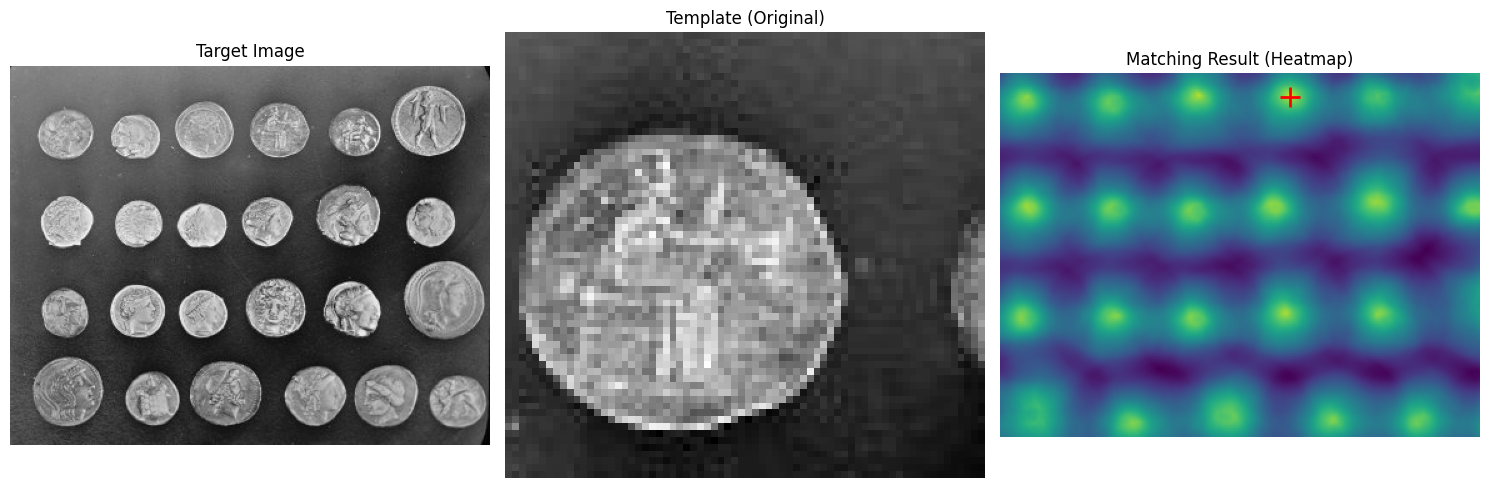


=== Uji Rotasi Template ===
Rotasi 15° - Koordinat terdeteksi: (189, 13) - Skor NCC: 0.747


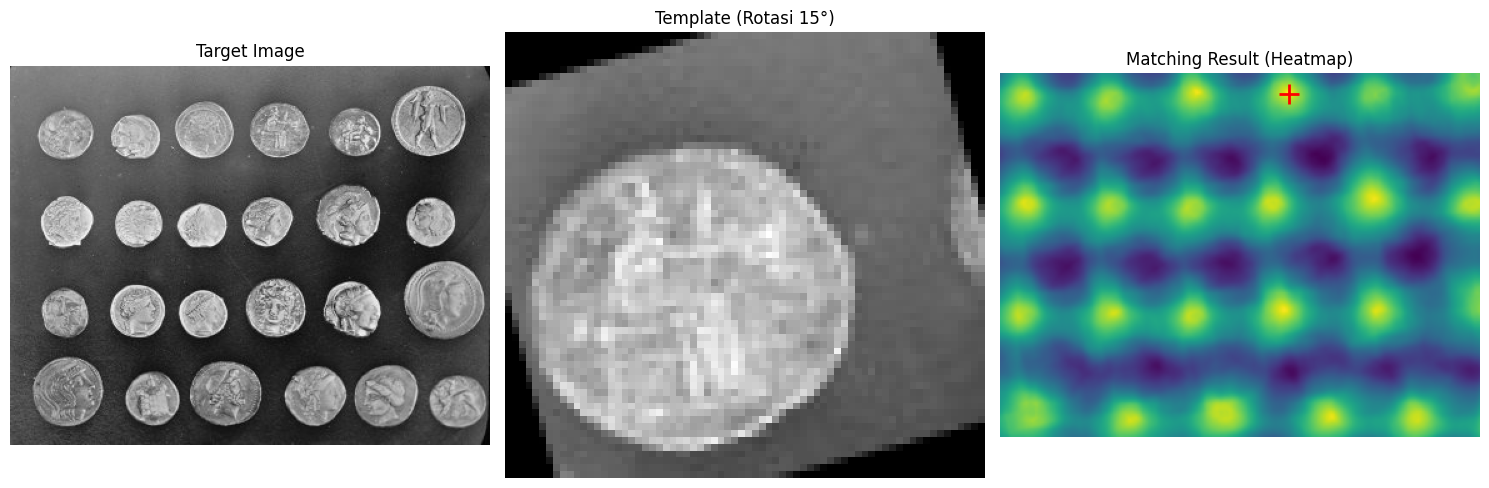

Rotasi 30° - Koordinat terdeteksi: (184, 153) - Skor NCC: 0.727


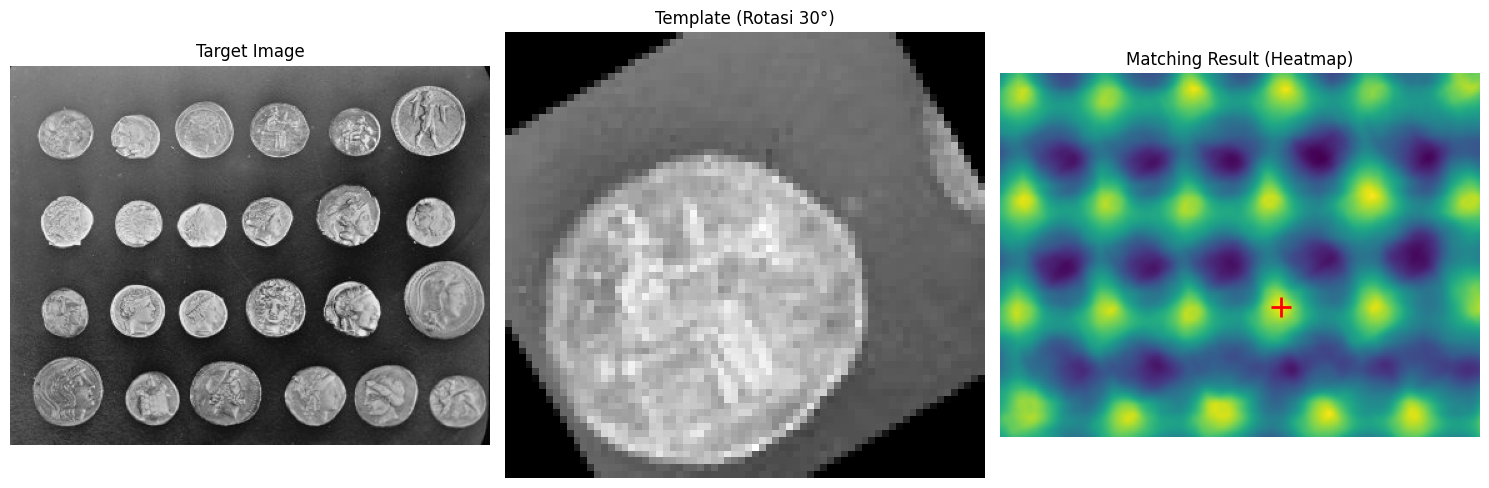

Rotasi 45° - Koordinat terdeteksi: (181, 151) - Skor NCC: 0.728


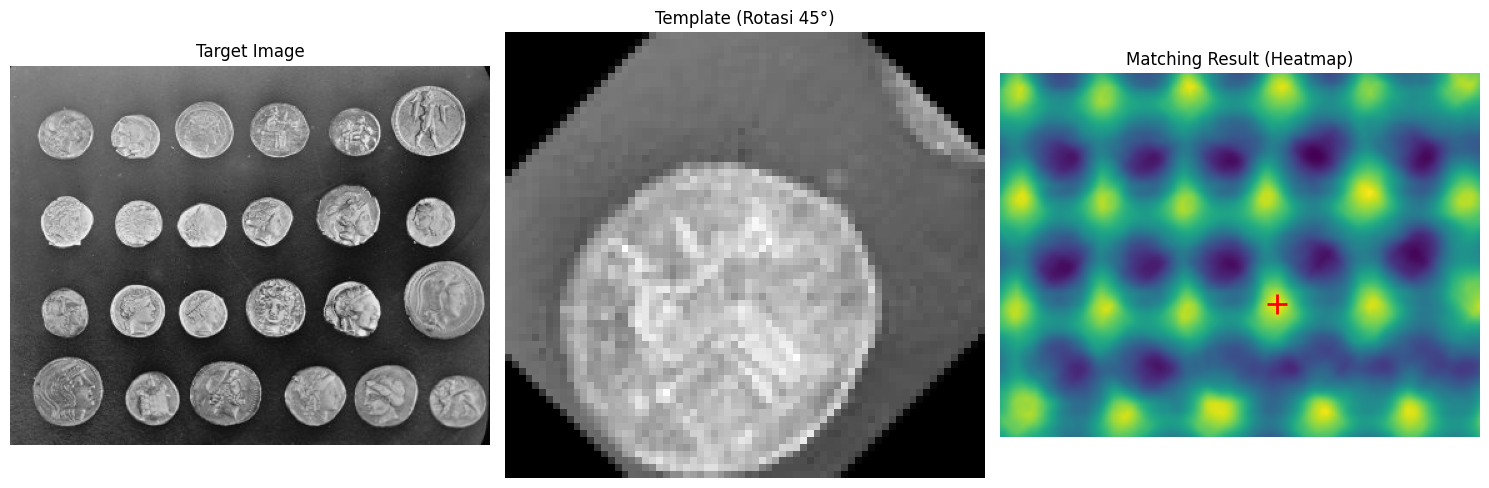


=== Uji Perubahan Skala Template ===
Skala 0.8x - Koordinat terdeteksi: (82, 97) - Skor NCC: 0.851


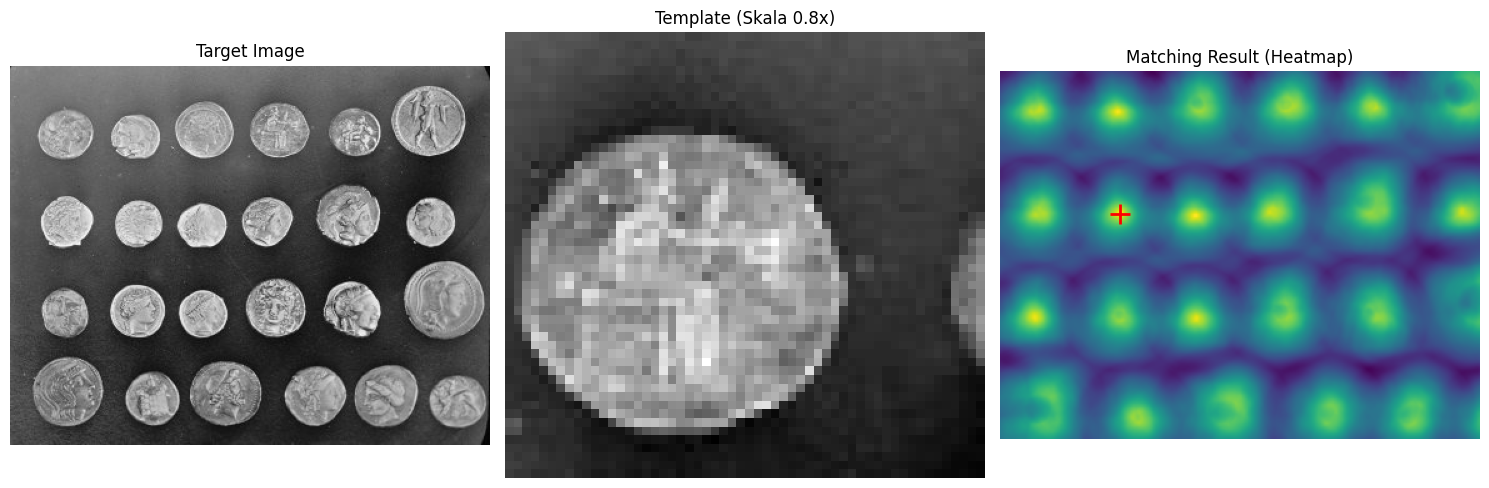

Skala 1.2x - Koordinat terdeteksi: (142, 218) - Skor NCC: 0.835


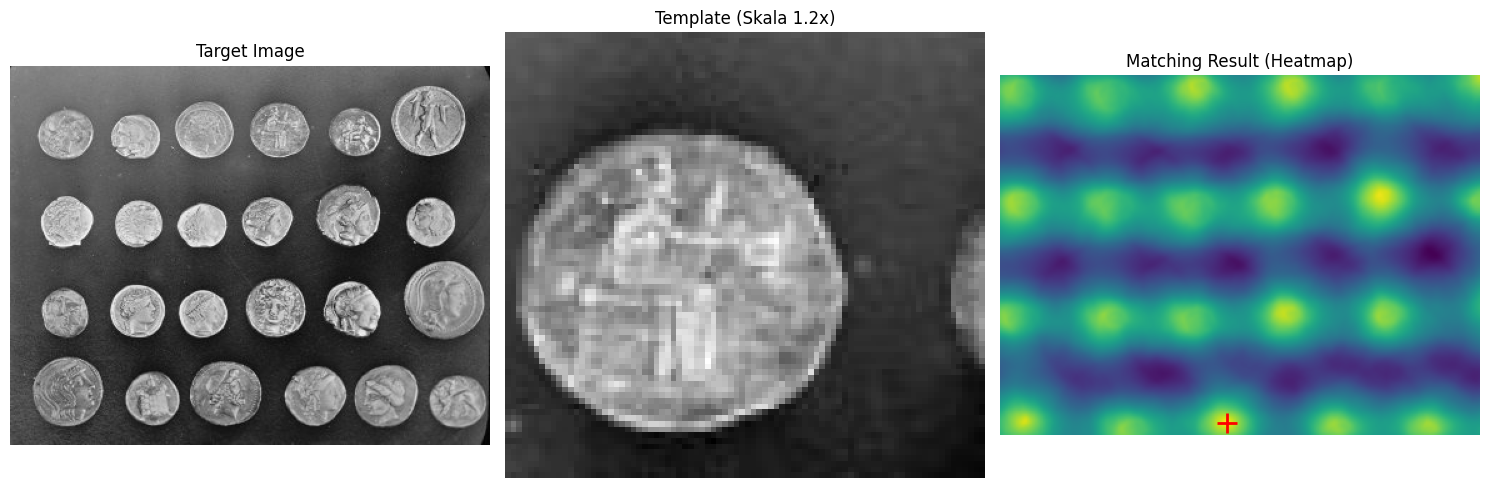

Skala 1.5x - Koordinat terdeteksi: (222, 67) - Skor NCC: 0.565


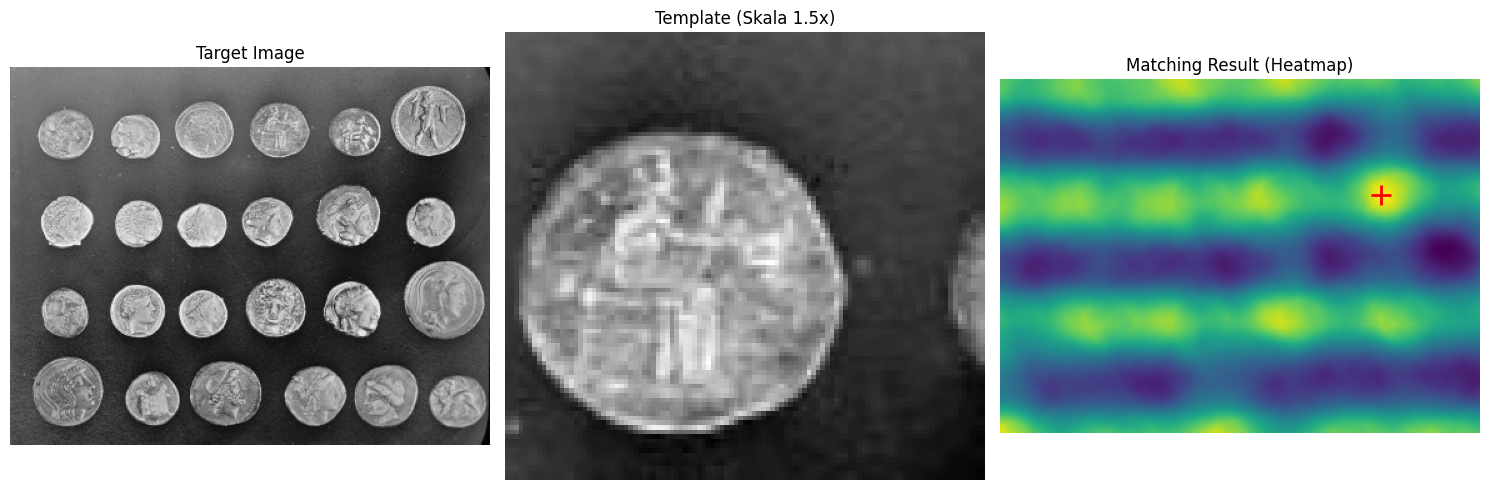

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

def load_images():
    """Load target image and extract template"""
    image = data.coins()
    template = image[15:80, 190:260]  # Extract one coin as template
    return image, template

def perform_template_matching(image, template):
    """Perform template matching using normalized cross-correlation"""
    result = match_template(image, template)
    return result

def find_best_match(result):
    """Find location with highest matching score"""
    ij = np.unravel_index(np.argmax(result), result.shape)
    x, y = ij[::-1]  # Convert to (x, y) coordinates
    return x, y

def visualize_results(image, template, result, x, y, title_suffix=""):
    """Visualize the matching results with custom title"""
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot target image
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Target Image')
    axes[0].set_axis_off()
    
    # Plot template
    axes[1].imshow(template, cmap='gray')
    axes[1].set_title(f'Template {title_suffix}')
    axes[1].set_axis_off()
    
    # Plot heatmap with best match marked
    axes[2].imshow(result, cmap='viridis')
    axes[2].set_title('Matching Result (Heatmap)')
    axes[2].set_axis_off()
    axes[2].plot(x, y, 'r+', markersize=15, markeredgewidth=2)
    
    plt.tight_layout()
    plt.show()

def test_rotation_invariance(image, template):
    """Test rotation invariance by rotating template"""
    print("\n=== Uji Rotasi Template ===")
    angles = [15, 30, 45]  # Derajat rotasi yang diuji
    
    for angle in angles:
        # Rotasi template
        rotated_template = rotate(template, angle=angle, resize=False)
        
        # Template matching
        result = match_template(image, rotated_template)
        x, y = find_best_match(result)
        
        # Hitung nilai NCC maksimum
        max_score = np.max(result)
        
        print(f"Rotasi {angle}° - Koordinat terdeteksi: ({x}, {y}) - Skor NCC: {max_score:.3f}")
        visualize_results(image, rotated_template, result, x, y, f"(Rotasi {angle}°)")

def test_scale_invariance(image, template):
    """Test scale invariance by resizing template"""
    print("\n=== Uji Perubahan Skala Template ===")
    scales = [0.8, 1.2, 1.5]  # Faktor skala yang diuji
    
    for scale in scales:
        # Ubah ukuran template
        scaled_template = rescale(template, scale=scale)
        
        # Template matching
        result = match_template(image, scaled_template)
        x, y = find_best_match(result)
        
        # Hitung nilai NCC maksimum
        max_score = np.max(result)
        
        print(f"Skala {scale}x - Koordinat terdeteksi: ({x}, {y}) - Skor NCC: {max_score:.3f}")
        visualize_results(image, scaled_template, result, x, y, f"(Skala {scale}x)")

def main():
    # 1. Load images
    image, template = load_images()
    
    # 2. Original template matching
    print("=== Template Matching Original ===")
    result = perform_template_matching(image, template)
    x, y = find_best_match(result)
    print(f"Koordinat terdeteksi: ({x}, {y}) - Skor NCC: {np.max(result):.3f}")
    visualize_results(image, template, result, x, y, "(Original)")
    
    # 3. Uji invariansi rotasi
    test_rotation_invariance(image, template)
    
    # 4. Uji invariansi skala
    test_scale_invariance(image, template)

if __name__ == "__main__":
    main()